# eALS on small data

Small, self-contained run of the eALS pipeline (He, Zhang, Kan & Chua,
*"Fast Matrix Factorization for Online Recommendation with Implicit
Feedback"*, SIGIR 2016), from `src/eals.py`, on data small enough to
check by hand: a synthetic implicit-feedback matrix with a known
community structure, plus an optional pass over a subsample of the real
Amazon data if it has already been downloaded and preprocessed.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "..", "src"))

import numpy as np
from pyspark.sql import SparkSession

from eals import EALS, EALSConfig
from evaluate import evaluate_sampled, evaluate_full


In [2]:
spark = SparkSession.builder.master("local[4]").appName("eals-demo").getOrCreate()
sc = spark.sparkContext
sc.setLogLevel("WARN")
# needed so the update functions are importable on the local executors too
sc.addPyFile(os.path.join("..", "src", "eals.py"))
print(spark.version)


26/08/30 03:16:50 WARN Utils: Your hostname, sepanta-inspiron resolves to a loopback address: 127.0.1.1; using 192.168.1.90 instead (on interface enx00e04c6831e5)
26/08/30 03:16:50 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/30 03:16:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


3.5.1


## 1. Small synthetic dataset

Three user communities of 15 users x 15 items each, 45 users and 45 items
in total, with interactions kept inside each community. A correct model
has no reason to mix latent directions across communities, so it should
rank each user's own community's items above the other two -- easy to
check by eye at this size.

In [3]:
def make_synthetic(n_communities=3, users_per=15, items_per=15, interactions_per_user=6, seed=0):
    rng = np.random.RandomState(seed)
    pairs = []
    n_users = n_communities * users_per
    n_items = n_communities * items_per
    for c in range(n_communities):
        user_ids = range(c * users_per, (c + 1) * users_per)
        item_pool = np.arange(c * items_per, (c + 1) * items_per)
        for u in user_ids:
            items = rng.choice(item_pool, size=interactions_per_user, replace=False)
            pairs += [(u, int(i)) for i in items]
    return pairs, n_users, n_items

all_pairs, n_users, n_items = make_synthetic()

# hold out each user's last interaction as the test item (leave-one-out)
train_user_items, train_pairs, test_pairs = {}, [], []
seen_per_user = {}
for u, i in all_pairs:
    seen_per_user.setdefault(u, []).append(i)
for u, items in seen_per_user.items():
    train_pairs += [(u, i) for i in items[:-1]]
    test_pairs.append((u, items[-1]))
    train_user_items[u] = set(items[:-1])

print(f"n_users={n_users} n_items={n_items} train={len(train_pairs)} test={len(test_pairs)}")


n_users=45 n_items=45 train=225 test=45


## 2. Train eALS

In [4]:
# trains on train_pairs; model.P / model.Q hold the learned user and item
# factors afterwards, and model.history the per-iteration loss
cfg = EALSConfig(n_factors=8, c0=32.0, alpha=0.4, reg=0.05, n_iters=20, n_partitions=4, seed=0)
model = EALS(cfg).fit(sc, n_users, n_items, train_pairs, verbose=True)


[eALS] iter 1/20  loss=145.7062


[eALS] iter 2/20  loss=97.6169


[eALS] iter 3/20  loss=91.3417


[eALS] iter 4/20  loss=88.7805


[eALS] iter 5/20  loss=87.1406


...

[eALS] iter 16/20  loss=83.9602


[eALS] iter 17/20  loss=83.9246


[eALS] iter 18/20  loss=83.8934


[eALS] iter 19/20  loss=83.8658


[eALS] iter 20/20  loss=83.8413


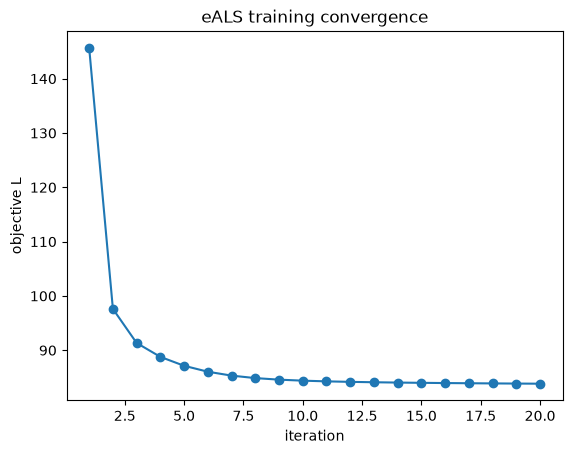

In [5]:
# objective should decrease roughly monotonically -- each coordinate update
# is an exact minimizer given the rest, so a wrong update would show up here
import matplotlib.pyplot as plt

iters = [h["iter"] for h in model.history]
losses = [h["loss"] for h in model.history]
plt.plot(iters, losses, marker="o")
plt.xlabel("iteration"); plt.ylabel("objective L"); plt.title("eALS training convergence")
plt.show()


## 3. Inspect the learned recommendations

In [6]:
# takes the trained model and one user id, prints that user's top-10 items
probe_user = 0
scores = model.score_all_items(probe_user)
top10 = np.argsort(-scores)[:10]
community_of = lambda item: item // 15
print(f"user {probe_user} belongs to community {community_of(probe_user * 1)} (users_per=15)")
print("top-10 recommended items (item_id, community, score):")
for item in top10:
    print(f"  item={item:2d}  community={community_of(item)}  score={scores[item]:.3f}")


user 0 belongs to community 0 (users_per=15)
top-10 recommended items (item_id, community, score):
  item= 6  community=0  score=0.795
  item= 1  community=0  score=0.722
  item= 9  community=0  score=0.658
  item= 8  community=0  score=0.602
  item=12  community=0  score=0.568
  item=13  community=0  score=0.522
  item= 7  community=0  score=0.448
  item= 5  community=0  score=0.443
  item= 4  community=0  score=0.384
  item=14  community=0  score=0.321


## 4. Offline leave-one-out evaluation (HR@K, NDCG@K)

In [7]:
# rank_full follows the paper exactly (whole catalog); the sampled version
# is what results/ uses for the large-scale runs, where ranking against
# the full ~22k-item catalog on every evaluation point would be too slow
full_metrics = evaluate_full(model.P, model.Q, test_pairs, train_user_items, k=10)
sampled_metrics = evaluate_sampled(model.P, model.Q, test_pairs, train_user_items, k=10, n_negatives=20, seed=0)
print("full-catalog ranking :", full_metrics)
print("sampled-negatives    :", sampled_metrics)


full-catalog ranking : {'HR@10': 0.7777777777777778, 'NDCG@10': 0.42364470924143843, 'n_test': 45}
sampled-negatives    : {'HR@10': 0.9111111111111111, 'NDCG@10': 0.5889705093992207, 'n_test': 45}


## 5. A peek at the real dataset (optional)

Runs the same pipeline on a 300-user subsample of the real Amazon data,
if `data/processed/` already exists (built by `src/preprocess.py`).
Skipped otherwise.

In [8]:
# reads data/processed/{train,test}.parquet, keeps only 300 users, and
# prints HR@10/NDCG@10 for that subsample at the end
import os as _os

data_dir = os.path.join("..", "data", "processed")
if not _os.path.isdir(os.path.join(data_dir, "train.parquet")):
    print("data/processed/ not found -- run src/preprocess.py first. Skipping.")
else:
    train_df = spark.read.parquet(f"{data_dir}/train.parquet")
    test_df = spark.read.parquet(f"{data_dir}/test.parquet")

    n_users_sample = 300
    sample_users = [r["user"] for r in train_df.select("user").distinct().limit(n_users_sample).collect()]
    sample_set = set(sample_users)

    real_train_pairs = [(r["user"], r["item"]) for r in train_df.collect() if r["user"] in sample_set]
    real_test_pairs = [(r["user"], r["item"]) for r in test_df.collect() if r["user"] in sample_set]
    real_n_users = max(u for u, _ in real_train_pairs) + 1
    real_n_items = max(i for _, i in real_train_pairs) + 1

    real_train_user_items = {}
    for u, i in real_train_pairs:
        real_train_user_items.setdefault(u, set()).add(i)

    print(f"subsample: {len(sample_users)} users, {len(real_train_pairs)} train interactions, "
          f"{len(real_test_pairs)} test interactions")

    real_cfg = EALSConfig(n_factors=16, c0=64.0, alpha=0.4, reg=0.01, n_iters=10, n_partitions=4)
    real_model = EALS(real_cfg).fit(sc, real_n_users, real_n_items, real_train_pairs, verbose=False)
    print(evaluate_sampled(real_model.P, real_model.Q, real_test_pairs, real_train_user_items, k=10))


subsample: 300 users, 9041 train interactions, 300 test interactions


{'HR@10': 0.28, 'NDCG@10': 0.1427601942928244, 'n_test': 300}


In [9]:
spark.stop()
